# Topic 1 : Machine Learning  
## Iris Flower Classification using Machine Learning Algorithms  

**Dataset:** Iris Dataset  
**Main Algorithm:** Random Forest  

</br></br>
<div style="display: flex; justify-content: center; gap: 10px;">
    <div style="text-align: center;">
        <img src="../img/Iris_setosa.jpg" style="width:230px; height:200px;"><br>
        <b>Setosa</b>
    </div>
    <div style="text-align: center;">
        <img src="../img/Iris_versicolor.jpg" style="width:230px; height:200px;"><br>
        <b>Versicolor</b>
    </div>
    <div style="text-align: center;">
        <img src="../img/Iris_virginica.jpg" style="width:230px; height:200px;"><br>
        <b>Virginica</b>
    </div>
</div>
</br></br>

---

## 1. Introduction  

### 1.1 Overview  
This project build a classification model that can predict the species of an iris flower based on its physical measurements. This is a supervised learning problem, where the model is trained on labeled data and learns patterns to classify new, unseen samples.  


### 1.2 Dataset Description  
The Iris dataset is one of the most well-known datasets in machine learning. It contains **150 samples** of iris flowers, each described by four numerical features:  

- **Sepal Length (cm)**  
- **Sepal Width (cm)**  
- **Petal Length (cm)**  
- **Petal Width (cm)**  

These features represent the input variables (**X**) used to train the model.  

The target variable (**y**) is the species of the flower, which includes three classes:  

- **Iris-setosa**  
- **Iris-versicolor**  
- **Iris-virginica**  

Each sample in the dataset corresponds to one flower, making it a multiclass classification problem.  


### 1.3 Algorithm: Random Forest  

In this project, we use the **Random Forest** algorithm for classification.  

Random Forest is an ensemble learning method that builds multiple decision trees during training and combines their predictions to improve accuracy and reduce overfitting. Instead of relying on a single model, it aggregates the results of many trees to produce a more robust and reliable prediction.  

Key characteristics of Random Forest:  

- It handles both linear and non-linear relationships  
- It reduces overfitting compared to a single decision tree  
- It provides good performance with minimal tuning  
- It can estimate feature importance  

Because of these advantages, Random Forest is well-suited for this classification task.  

---

## 2. Step 1: Data Preparation

### 2.1 Import libraries
In this step  we will import all the required libraries

In [1]:
#run "pip install -r requirements.txt" in the terminal to install the required libraries

import numpy as np
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score,confusion_matrix
from sklearn.preprocessing import LabelEncoder

print("Libraries imported successfully")

Libraries imported successfully


### 2.2 Load the Dataset

We load the Iris dataset into a Pandas DataFrame. This allows us to easily explore, manipulate, and prepare the data for machine learning.

In [2]:
# Load the dataset
df = pd.read_csv("../data/iris_dataset.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### 2.3 Distribution of the Dataset

This helps to check whether the dataset is balanced or if some classes are overrepresented.

In [3]:
# Drop the 'Id' column since it does not provide useful information for model training
df = df.drop(columns=['Id'])

# Extract the unique species names from the dataset
species_names = df["Species"].unique()
print(species_names)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [4]:
# Class distribution
print("Distribution:")
class_dist = df['Species'].value_counts()
print(class_dist)

Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
# Check empty field
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Class Distribution

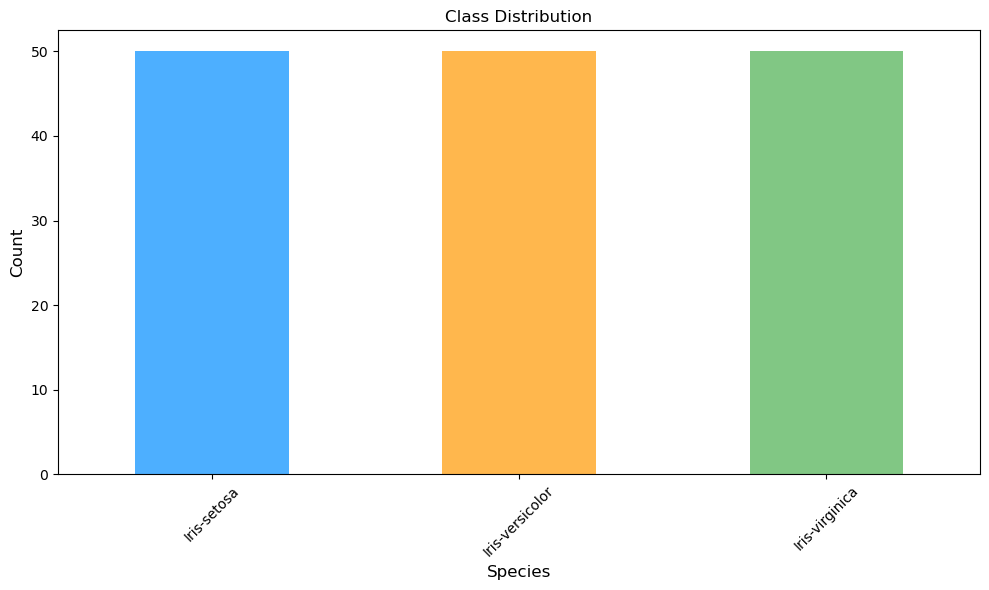

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
class_dist.plot(kind='bar', ax=ax, color=["#4DAFFF", '#FFB74D','#81C784'])
ax.set_title('Class Distribution', fontsize=12)
ax.set_xlabel('Species', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], rotation=45)
plt.tight_layout()
plt.savefig("../img/output/class_dist", dpi=150)
plt.show()

Exploratory Data Analysis (EDA)

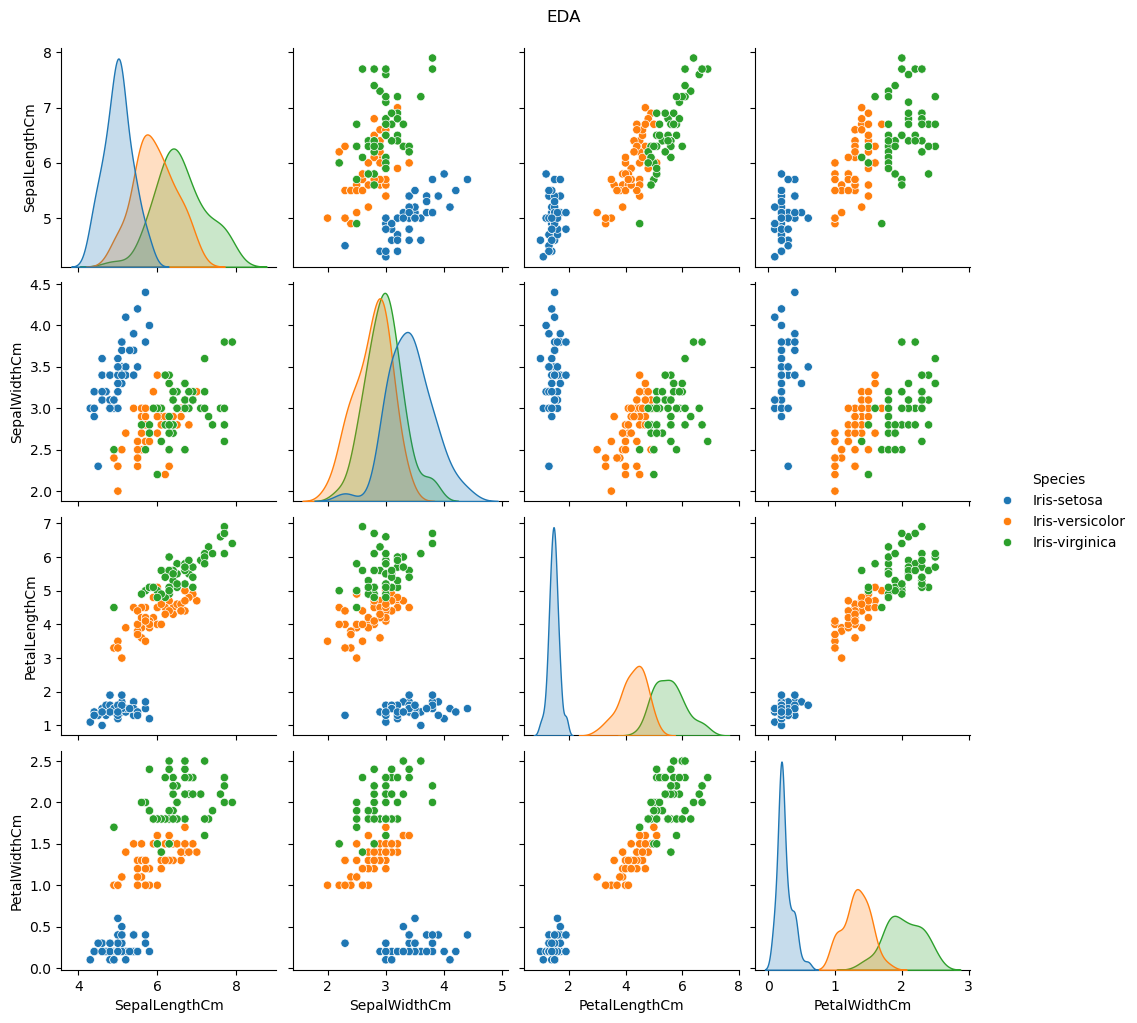

In [8]:
eda = sbn.pairplot(df, hue="Species")
eda.fig.suptitle("EDA", y=1.02, fontsize=12)

eda.savefig("../img/output/eda", dpi=150)

Violin Plot

A violin plot is basically a distribution visualizer. In your 2×2 figure, each subplot shows how a feature (sepal length, sepal width, petal length, petal width) is distributed across the three Iris species.

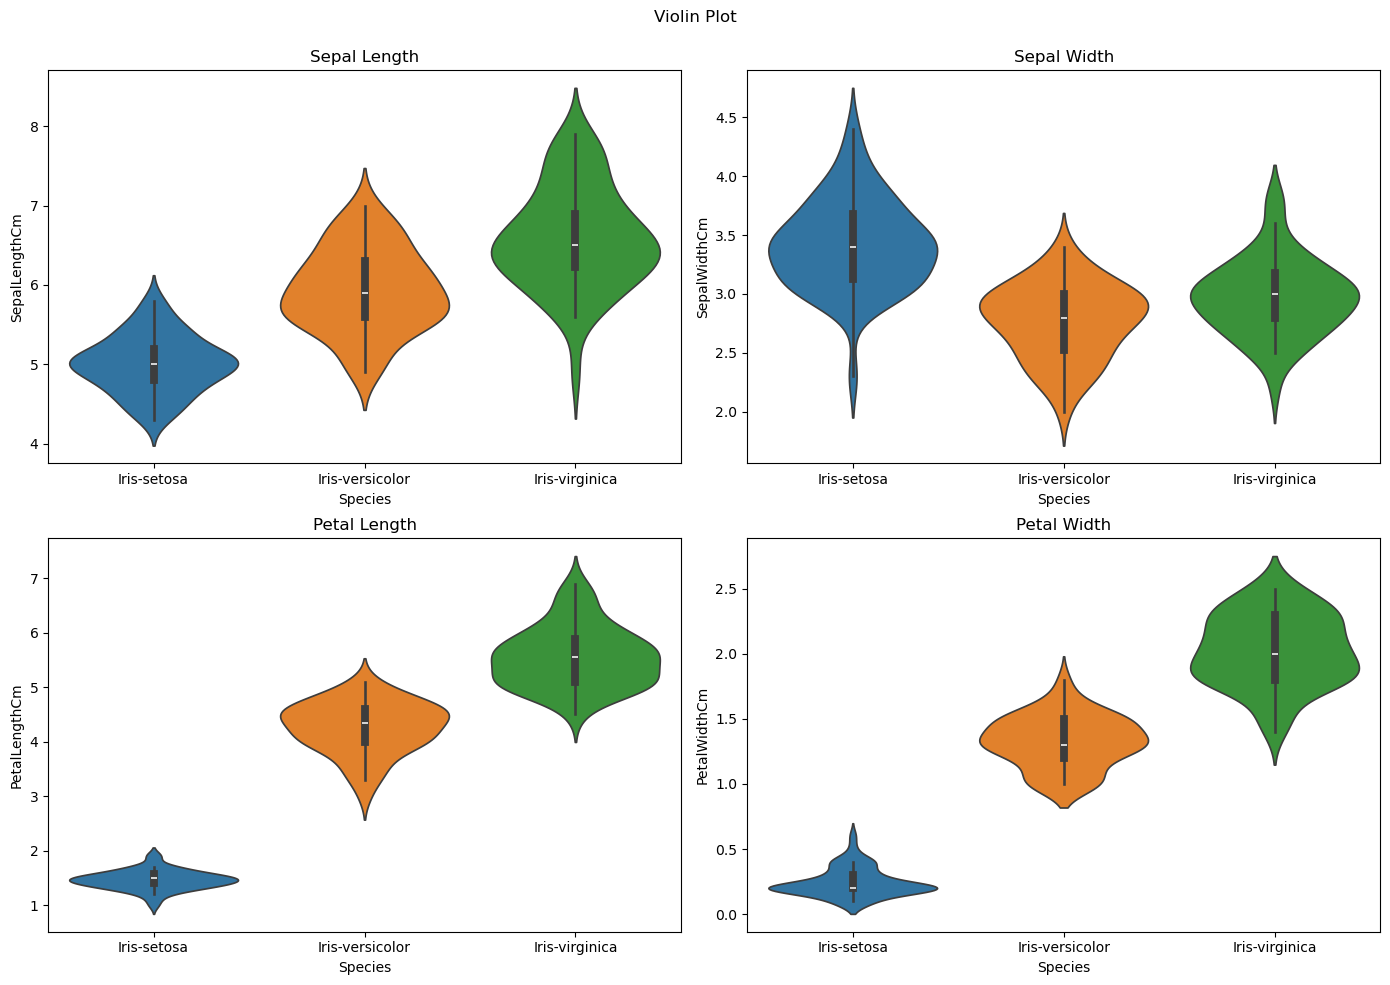

In [9]:
# Optional: Clean column names
df.columns = df.columns.str.strip()

custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Sepal Length
sbn.violinplot(
    x='Species', y='SepalLengthCm',
    data=df, hue='Species',
    palette=custom_colors,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Sepal Length")

# Plot 2: Sepal Width
sbn.violinplot(
    x='Species', y='SepalWidthCm',
    data=df, hue='Species',
    palette=custom_colors,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Sepal Width")

# Plot 3: Petal Length
sbn.violinplot(
    x='Species', y='PetalLengthCm',
    data=df, hue='Species',
    palette=custom_colors,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Petal Length")

# Plot 4: Petal Width
sbn.violinplot(
    x='Species', y='PetalWidthCm',
    data=df, hue='Species',
    palette=custom_colors,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Petal Width")

# Improve layout
plt.tight_layout()
fig.suptitle("Violin Plot", fontsize=12)
plt.subplots_adjust(top=0.92)
plt.savefig("../img/output/violin_plot", dpi=150)
plt.show()

### 2.4 Statistics

Generate a statistical summary of the dataset to understand the distribution of the numerical features.

In [10]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


We group the dataset by species and compute summary statistics (minimum, maximum, and mean) for each feature. 

This helps us understand how the characteristics of each species differ.

In [11]:
df.groupby("Species").agg(['min','max','mean'])

SepalLengthCm             SepalWidthCm              \
                          min  max   mean          min  max   mean   
Species                                                              
Iris-setosa               4.3  5.8  5.006          2.3  4.4  3.418   
Iris-versicolor           4.9  7.0  5.936          2.0  3.4  2.770   
Iris-virginica            4.9  7.9  6.588          2.2  3.8  2.974   

                PetalLengthCm             PetalWidthCm              
                          min  max   mean          min  max   mean  
Species                                                             
Iris-setosa               1.0  1.9  1.464          0.1  0.6  0.244  
Iris-versicolor           3.0  5.1  4.260          1.0  1.8  1.326  
Iris-virginica            4.5  6.9  5.552          1.4  2.5  2.026

### 2.5 Correlation Matrix

The correlation matrix shows relationships between features in the dataset. 

Petal length and petal width are strongly correlated, making them important for classification, while sepal features are less correlated.

In [12]:
df.drop(columns=["Species"]).corr()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


Correlation  matrix


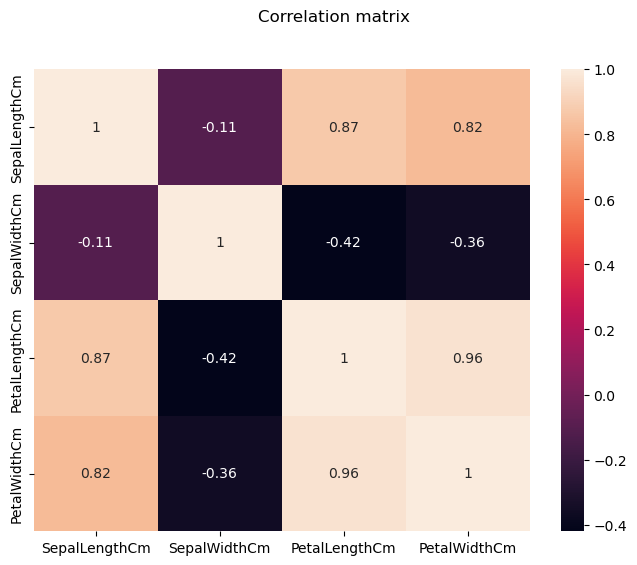

In [13]:
corr = df.drop(columns=["Species"]).corr()

fig, ax = plt.subplots(figsize=(8,6))
sbn.heatmap(corr, annot=True, ax=ax)
print("Correlation  matrix")
fig.suptitle("Correlation matrix", fontsize=12)
plt.savefig("../img/output/corr_matrix", dpi=150)
plt.show()

### 2.6 Encoding

Machine learning models cannot directly work with categorical data (text labels).  
Therefore, we need to convert the target variable (**Species**) into numerical values.

This process is called **label encoding**.

The mapping used in this dataset is:

- Iris-setosa       → 0  
- Iris-versicolor   → 1  
- Iris-virginica    → 2  

In [14]:
# Encode the 'Species' column to numerical values
label_enco = LabelEncoder()
df['Species'] = label_enco.fit_transform(df['Species'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
# Display unique species : 0 = Iris-setosa, 1 = Iris-versicolor, 2 = Iris-virginica
print(df['Species'].unique())

[0 1 2]


### 2.7 Dataset Splitting

In machine learning, the dataset is divided into two parts:

- **Training set**: used to train the model
- **Test set**: used to evaluate the model on unseen data

This helps to measure how well the model generalizes to new inputs.

In this project we split the dataset into 70% for training and 30% for test

In [16]:
# Prepare the data for training and testing (70% training, 30% testing)
X_feature = df.drop(columns=['Species'])
y_species = df['Species']
test_size = 0.3
random_state = 70
X_feature_train, X_feature_test, y_species_train, y_species_test = train_test_split(X_feature, y_species, test_size=test_size, random_state=random_state)

## 3. Step 2: Training and Evaluating Models

In this step, we train a model to classify Iris flower species based on their features.

The dataset is split into two parts:
- The training set is used to train the model.
- The test set is used to evaluate its performance on unseen data.

We use a Random Forest classifier to build the model. It is chosen because it is robust, accurate, and performs well with complex relationships in the data.

After training, the model makes predictions on the test set. Its performance is then measured using accuracy, which shows the proportion of correct predictions.

This step helps evaluate how well the model can handle new, unseen data.

### 3.1 Evaluation Function

We define a function to evaluate the performance of the model using accuracy.

The function compares the predicted values with the actual values and displays:
- The accuracy score in percentage
- A performance status based on the accuracy level (e.g., good, very good, perfect)

This helps to quickly interpret how well the model is performing.

In [17]:
def evaluate_model(y_true, y_pred):
    model_accuracy_score = accuracy_score(y_true, y_pred) * 100
    precision = precision_score(y_true, y_pred, average='macro') * 100
    f1 = f1_score(y_true, y_pred, average='macro') * 100

    # Color mapping
    if model_accuracy_score >= 90:
        color = "\033[92m"  # green
    elif model_accuracy_score >= 50:
        color = "\033[93m"  # yellow
    else:
        color = "\033[91m"  # red

    print(f"Accuracy : {color}{model_accuracy_score:.2f}%\033[0m")
    print(f"Precision: {precision:.2f}%")
    print(f"F1-score : {f1:.2f}%")

    # Status logic based on accuracy score
    status_list = [
        "Perfect model",
        "Very good model",
        "Good model",
        "Bad model",
        "Very bad model"
    ]

    if model_accuracy_score == 100:
        status = status_list[0]
    elif model_accuracy_score >= 90:
        status = status_list[1]
    elif model_accuracy_score >= 50:
        status = status_list[2]
    elif model_accuracy_score >= 0:
        status = status_list[3]
    else:
        status = status_list[4]

    print(f"\nStatus   : {status}")

### 3.2 Random Forest Model Training

A Random Forest classifier is trained using the training data.

The model is then used to predict the species of the test samples.

After training, the model is saved using Joblib for future reuse without retraining.

In [18]:
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_feature_train, y_species_train)
y_species_pred = rf_model.predict(X_feature_test)

print("Random Forest model trained and predictions completed successfully.")

Random Forest model trained and predictions completed successfully.


### 3.3 Model Evaluation

We evaluate the trained model using different metrics to measure its performance on unseen data.

These metrics include:
- Accuracy: overall correctness of predictions  
- Precision: how many predicted values are correct   
- F1-score: balance between precision and recall  

This helps to better understand how well the model performs beyond just accuracy.

In [19]:
print("Random Forest Classifier - Evaluation Results\n")
evaluate_model(y_species_test, y_species_pred)

Random Forest Classifier - Evaluation Results

Accuracy : 97.78%
Precision: 98.04%
F1-score : 97.66%

Status   : Very good model


### 3.4 Confusion matrix

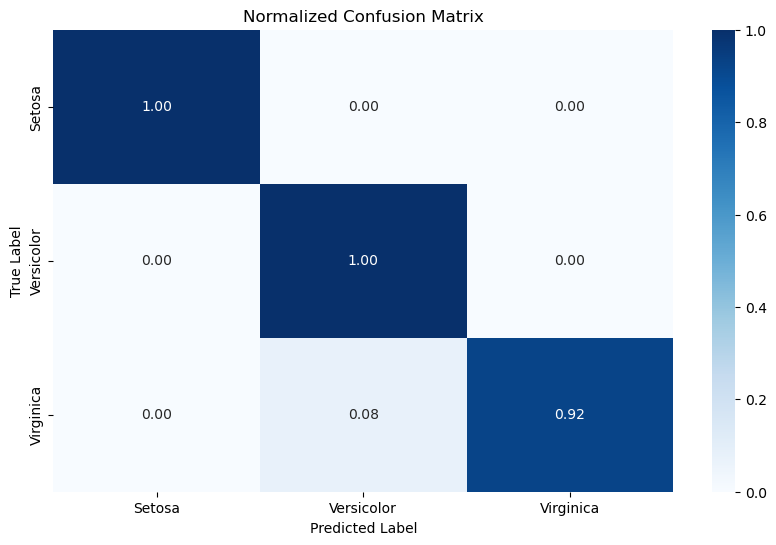

In [20]:
y_species_pred = rf_model.predict(X_feature_test)

cm = confusion_matrix(y_species_test, y_species_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 6))

sbn.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["Setosa", "Versicolor", "Virginica"],
    yticklabels=["Setosa", "Versicolor", "Virginica"]
)

plt.title("Normalized Confusion Matrix", fontsize=12)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("../img/output/conf_matrix", dpi=150)
plt.show()

In [21]:
joblib.dump(rf_model, "../app/iris_model.pkl")
# rf_model = joblib.load("../app/iris_model.pkl")

['../app/iris_model.pkl']

## 4. Step 3: Display the Classification Effect

In this step, we visualize the performance of the trained machine learning model.

### 4.1 Sample Data Visualization
We first display the original dataset using a scatter plot. This helps us understand how the different Iris species are distributed based on their features (Petal Length and Petal Width).

Each point represents a sample, and colors represent different species. This visualization helps us observe how separable the classes are before applying the model.

Data visualization before decision boundary


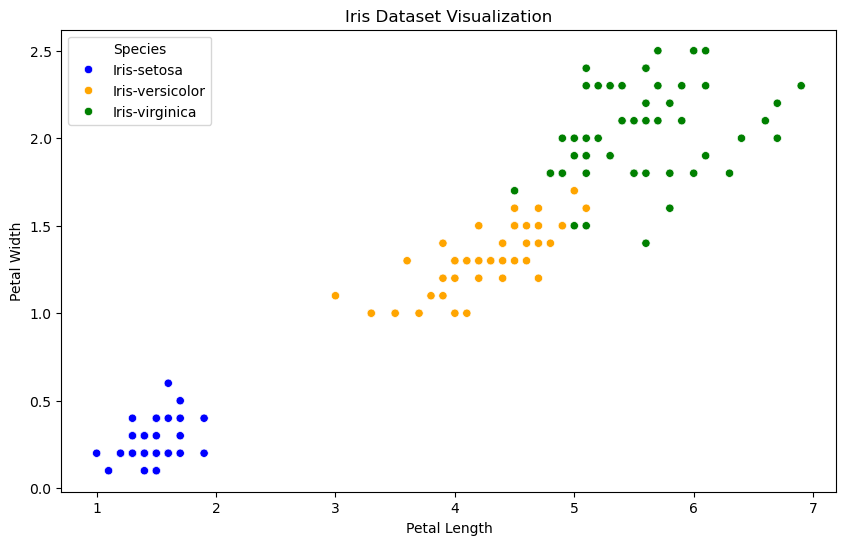

In [22]:
# visualisation of data

df['species_name'] = df['Species'].map({
    0: 'Iris-setosa',
    1: 'Iris-versicolor',
    2: 'Iris-virginica'
})

colors = {
    'Iris-setosa': 'blue',
    'Iris-versicolor': 'orange',
    'Iris-virginica': 'green'
    
}

plt.figure(figsize=(10, 6))

sbn.scatterplot(
    x=df.iloc[:, 2], 
    y=df.iloc[:, 3], 
    hue=df['species_name'], 
    palette=colors
)

print("Data visualization before decision boundary")

plt.title('Iris Dataset Visualization', fontsize=12)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend(title='Species')
plt.savefig("../img/output/data_viz", dpi=150)
plt.show()

### 4.2 Decision Boundary Visualization
We then plot the decision boundary of the trained model (Random Forest). This shows how the model divides the feature space into different regions corresponding to each class.

By comparing the sample data with the decision boundary, we can visually evaluate how well the model has learned to separate the classes.

Random Forest Decision Boundary Visualization


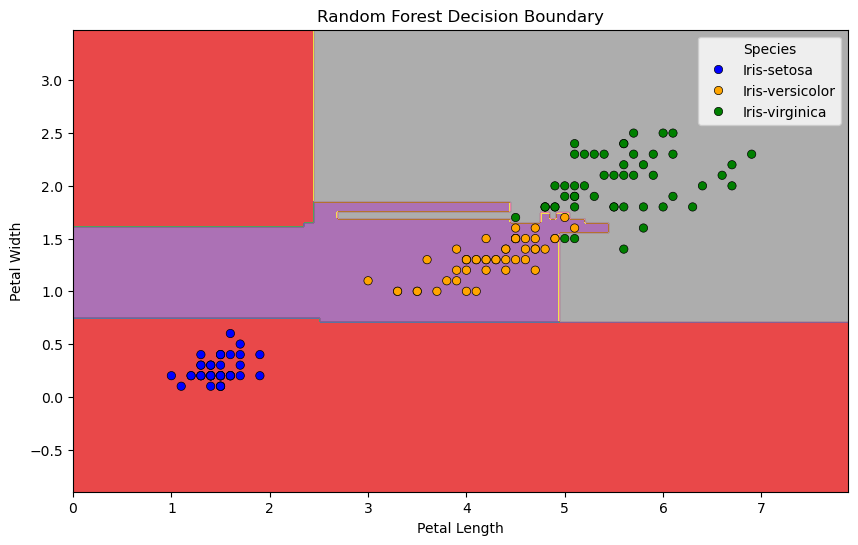

In [23]:
#Descision Boundary

X_2d = X_feature.iloc[:, 2:4].values

test_size = 0.3
random_state = 70

X_feature_train2, X_feature_test2, y_species_train2, y_species_test2 = train_test_split(X_2d, y_species, test_size=test_size, random_state=random_state)
n_trees = 100
rf_desBound_model = RandomForestClassifier(n_estimators=n_trees)
rf_desBound_model.fit(X_feature_train2, y_species_train2)

X_min, X_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(X_min, X_max, 0.02), 
    np.arange(y_min, y_max, 0.02)
)

Z = rf_desBound_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap='Set1')
sbn.scatterplot(
    x=X_2d[:, 0], 
    y=X_2d[:, 1], 
    hue=df['species_name'], 
    palette=colors, 
    edgecolor='k'
)

print("Random Forest Decision Boundary Visualization")

plt.title('Random Forest Decision Boundary', fontsize=12)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend(title='Species')
plt.savefig("../img/output/desc_bound", dpi=150)
plt.show()


In [24]:
joblib.dump(rf_desBound_model, "../app/descision_boundary.pkl")

['../app/descision_boundary.pkl']

### 4.3 Decision Boundary with PCA

To better visualize how the model separates the different iris species, we reduce the dataset to 2 dimensions using **Principal Component Analysis (PCA)**.

PCA transforms the original 4 features (Sepal Length, Sepal Width, Petal Length, Petal Width) into 2 new components while preserving as much information **(variance)** as possible.

We then train a Random Forest classifier on this 2D representation and plot its decision boundaries. This allows us to clearly see how the model divides the feature space between the three flower classes.

Although this is a simplified projection of the original data, it provides an intuitive understanding of how the model separates the classes visually.

Random Forest PCA Decision Boundary Visualization


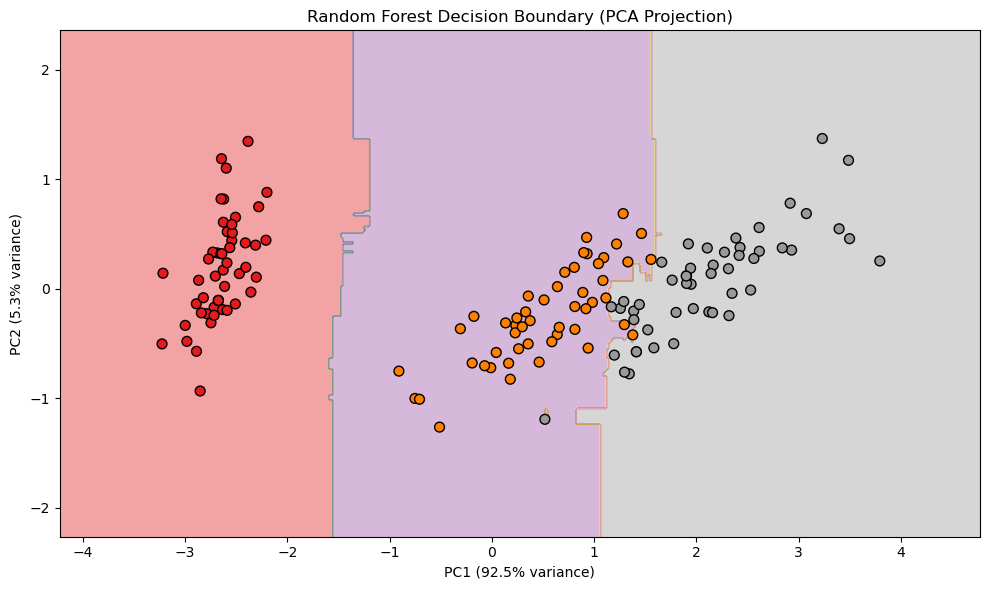

In [25]:
from sklearn.decomposition import PCA

X = X_feature
y = y_species

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

n_tree = 100
state = 42

rf_viz_pca = RandomForestClassifier(n_estimators=n_tree, random_state=state)
rf_viz_pca.fit(X_pca, y)

h = 0.02
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = rf_viz_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 6))

ax.contourf(xx, yy, Z, alpha=0.4, cmap='Set1')

# Data points
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=pd.Categorical(y).codes,
    cmap='Set1',
    edgecolors='black',
    s=50
)

ax.set_xlabel(
    f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)'
)
ax.set_ylabel(
    f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)'
)

print("Random Forest PCA Decision Boundary Visualization")

ax.set_title("Random Forest Decision Boundary (PCA Projection)", fontsize=12)

plt.tight_layout()
plt.savefig("../img/output/pca", dpi=150)
plt.show()

## 5. Manual Test

In [26]:
"""""

# Prediction function for new flower data
def predict_flower(sepal_length, sepal_width, petal_length, petal_width):
    features = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    prediction = rfc_model.predict(features)[0]

    mapping = {
        0: "Iris-setosa",
        1: "Iris-versicolor",
        2: "Iris-virginica"
    }

    return mapping[prediction]


sepal_length = 5.1
sepal_width = 3.5
petal_length = 1.4
petal_width = 5.0

5.0, 3.6, 1.4, 0.2 : Iris-setosa
5.2, 2.7, 3.9, 1.4 : Iris-versicolor
6.5, 3.2, 5.1, 2.0 : Iris-virginica



sepal_length = float(input("Enter sepal length: "))
sepal_width = float(input("Enter sepal width: "))
petal_length = float(input("Enter petal length: "))
petal_width = float(input("Enter petal width: "))

new_flower = [sepal_length, sepal_width, petal_length, petal_width]
predicted_species = predict_flower(*new_flower)
print(f"Predicted species for features {new_flower} : {predicted_species}")

"""""


'""\n\n# Prediction function for new flower data\ndef predict_flower(sepal_length, sepal_width, petal_length, petal_width):\n    features = np.array([[sepal_length, sepal_width, petal_length, petal_width]])\n    prediction = rfc_model.predict(features)[0]\n\n    mapping = {\n        0: "Iris-setosa",\n        1: "Iris-versicolor",\n        2: "Iris-virginica"\n    }\n\n    return mapping[prediction]\n\n\nsepal_length = 5.1\nsepal_width = 3.5\npetal_length = 1.4\npetal_width = 5.0\n\n5.0, 3.6, 1.4, 0.2 : Iris-setosa\n5.2, 2.7, 3.9, 1.4 : Iris-versicolor\n6.5, 3.2, 5.1, 2.0 : Iris-virginica\n\n\n\nsepal_length = float(input("Enter sepal length: "))\nsepal_width = float(input("Enter sepal width: "))\npetal_length = float(input("Enter petal length: "))\npetal_width = float(input("Enter petal width: "))\n\nnew_flower = [sepal_length, sepal_width, petal_length, petal_width]\npredicted_species = predict_flower(*new_flower)\nprint(f"Predicted species for features {new_flower} : {predicted_spec